# Preparing 4 versions of TabPFN and save

In [ ]:
# DON'T RUN this cell - First-ever run only; Install 4 versions of TabPFN

# google drive
from google.colab import drive
drive.mount('/content/drive')
MAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/"

# IBE server
#MAIN_PATH = "/raid/www/nextcloud/data/alireza.ghorbani/files/20250727_tabpfn_[paper]/"

# Local
#MAIN_PATH = "D:/Documents/github/benchmark-tabpfn-medical/"

import sys
sys.path.append(MAIN_PATH)

from src.setup_vendor import setup_vendor
setup_vendor(MAIN_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
scikit‑learn package version: 1.7.2
XGBoost package version: 3.4.1
CatBoost package version: 1.2.10


# Installing Dependencies

In [2]:
# google drive
from google.colab import drive
drive.mount('/content/drive')
MAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/"

# IBE server
#MAIN_PATH = "/raid/www/nextcloud/data/alireza.ghorbani/files/20250727_tabpfn_[paper]/"

# Local
#MAIN_PATH = "D:/Documents/github/benchmark-tabpfn-medical/"

# Install dependencies
!pip install -q -r "{MAIN_PATH}requirements.txt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After restarting runtime, run next cell.


# Load the Core Functions and Check Packages

In [1]:
# google drive
from google.colab import drive
drive.mount('/content/drive')
MAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/"

# IBE server
#MAIN_PATH = "./20250727_tabpfn_[paper]/"

# Local
#MAIN_PATH = "D:/Documents/github/benchmark-tabpfn-medical/"
#MAIN_PATH = "./benchmark-tabpfn-medical/"

import sys
sys.path.append(MAIN_PATH)
import src

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
scikit‑learn package version: 1.7.2
XGBoost package version: 3.4.1
CatBoost package version: 1.2.10
tabpfn_v25 loaded
tabpfn_v26 loaded
tabpfn_v3 loaded
tabpfn_v35 loaded
EXAONE package version: 1.0.0
TabICL package version: 2.2.0


# Simualtions and Resamplings

## Run simulations

In [ ]:
# Run all the baseline simualtions
from src import simulation, save_outputs, SETTINGS

for sid, cfg in SETTINGS.items():
    print(f"\n{'='*60}\nSetting {sid}: {cfg['label']}\n{'='*60}")

    kwargs = dict(
        n=cfg['n'],
        mu=cfg['mu'],
        sigma1=cfg['sigma1'],
        sigma2=cfg['sigma2'],
        dist=cfg['dist'],
        iter=2,
        g_seed=2025,
    )
    if 'df' in cfg:
        kwargs['df'] = cfg['df']

    errors, warns = simulation(**kwargs)

    meta = {
        'setting_id': sid,
        'label': cfg['label'],
        'n': cfg['n'],
        'mu': cfg['mu'],
        'dist': cfg['dist'],
        'df': cfg.get('df', None),
        'dim': int(len(cfg['mu']['mu1'])),
        'iter': 2,
        'g_seed': 2025,
    }
    save_outputs(errors, f'simulation_setting{sid}', meta=meta)

## Run Sensitivity Simulation

In [ ]:
# Run all the sensitivity simualtions
from src import SENSITIVITY

for sid, cfg in SENSITIVITY.items():
    print(f"\n{'='*60}\nSensitivity {sid}: {cfg['label']}\n{'='*60}")

    kwargs = dict(
        n=cfg['n'],
        mu=cfg['mu'],
        sigma1=cfg['sigma1'],
        sigma2=cfg['sigma2'],
        dist=cfg['dist'],
        iter=2,
        g_seed=2026,
    )
    if 'df' in cfg:
        kwargs['df'] = cfg['df']

    errors, warns = simulation(**kwargs)

    meta = {
        'setting_id': sid,
        'label': cfg['label'],
        'n': cfg['n'],
        'mu': cfg['mu'],
        'dist': cfg['dist'],
        'df': cfg.get('df', None),
        'dim': int(len(cfg['mu']['mu1'])),
        'iter': 2,
        'g_seed': 2026,
        'variant': 'sensitivity',
    }
    save_outputs(errors, f'simulation_setting{sid}_sensitivity', meta=meta)

In [ ]:
# Setting 2++
import pandas as pd

from src.config import SIM_RESULTS_PATH, TABLES_PATH
from src.settings import SETTINGS
from src import simulation
from src.utils import save_outputs
from src.table_functions import build_measures_table

cfg = SETTINGS[2]
n_plus = {'n1_tr': 10000, 'n2_tr': 10000, 'n1_te': 500, 'n2_te': 500}

errors_plus, warns = simulation(
    n_plus, cfg['mu'], cfg['sigma1'], cfg['sigma2'],
    dist='Normal', df=5, iter=10, g_seed=2027,
)

save_outputs(errors_plus, 'simulation_setting2_plus', meta={
    'setting_id': '2+',
    'label': 'Setting 2+: n_tr=10000',
    'n': n_plus,
    'dist': 'Normal',
    'iter': 10,
    'g_seed': 2027,
})

plus = {'2+': pd.read_csv(f'{SIM_RESULTS_PATH}simulation_setting2_plus.csv')}

display(build_measures_table(
    plus,
    metrics=['AUC', 'Brier', 'Time'],
    filename='sim_setting2_plus.csv',
    tables_dir=TABLES_PATH,
))

## Run real data evaluation

In [ ]:
# Run all the real data resampling
from src import (
    evaluate_on_real_data, save_outputs,
    load_echo_data, load_glucose_data, load_blood_gas_data,
)
from src.config import REAL_DATA_PATH, REAL_RESULTS_PATH

datasets = [
    ('case_study_1_echo_notes',                 load_echo_data),
    ('case_study_2_blood_glucose_management_1', load_glucose_data),
    ('case_study_3_blood_gas_oximetry',         load_blood_gas_data),
]

for name, loader in datasets:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    X, y, groups = loader(REAL_DATA_PATH)
    print("X Shape:", X.shape, "y Shape:", y.shape, "groups:", groups.nunique(), "patients")
    errors = evaluate_on_real_data(
        X=X, y=y,
        n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
        iter=500, g_seed=2025,
    )
    meta = {
        'dataset': name,
        'n': {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
        'iter': 500,
        'g_seed': 2025,
        'n_features': int(X.shape[1]),
        'n_samples': int(X.shape[0]),
        'groups': int(groups.nunique()) if hasattr(groups, 'nunique') else None,
    }
    save_outputs(errors, f'realdata_{name}',
                 output_dir=REAL_RESULTS_PATH, meta=meta)

# Results

## Tables

In [2]:
# All RESULTS
import pandas as pd
from src.config import SIM_RESULTS_PATH, REAL_RESULTS_PATH, TABLES_PATH
from src.utils import discover_sim, discover_real, load_fixed
from src.table_functions import build_measures_table, build_gain_table

baseline    = load_fixed(discover_sim(SIM_RESULTS_PATH, 'baseline'))
sensitivity = load_fixed(discover_sim(SIM_RESULTS_PATH, 'sensitivity'))
real_data   = load_fixed(discover_real(REAL_RESULTS_PATH))

print("baseline settings   :", list(baseline.keys()))
print("sensitivity settings:", list(sensitivity.keys()))
print("real datasets       :", list(real_data.keys()))


# 1. Baseline
if baseline:
    display(build_measures_table(
        baseline,
        filename='sim_baseline.csv',
        tables_dir=TABLES_PATH,
    ))
else:
    print("⚠️ no baseline files")

# 2. Sensitivity
if sensitivity:
    display(build_measures_table(
        sensitivity,
        filename='sim_sensitivity.csv',
        tables_dir=TABLES_PATH,
    ))
else:
    print("⚠️ no sensitivity files")

# 3. Gains
common = sorted(set(baseline) & set(sensitivity))
if common:
    display(build_gain_table(
        {s: baseline[s]    for s in common},
        {s: sensitivity[s] for s in common},
        metric='AUC',
        filename='sim_gains_auc.csv',
        tables_dir=TABLES_PATH,
    ))
else:
    print("⚠️ no common settings between baseline and sensitivity")

# 4. Real data
if real_data:
    display(build_measures_table(
        real_data,
        filename='realdata.csv',
        tables_dir=TABLES_PATH,
    ))
else:
    print("⚠️ no realdata files")


baseline settings   : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
sensitivity settings: ['S1']
real datasets       : []
✓ sim_baseline.csv


✓ sim_sensitivity.csv


✓ sim_gains_auc.csv


,L-SLR,SLR,RandomForest,XGBoost,CatBoost,TabPFN_v25,TabPFN_v26,TabPFN_v3,TabPFN_v35,EXAONE,TabICL-V2
Setting,,,,,,,,,,,
S1,+0.015,+0.068,+0.024,+0.029,+0.025,+nan,+nan,+nan,+nan,+nan,+nan


⚠️ no realdata files


## PLots

In [4]:
# PLots
from src.utils import discover_sim, discover_real, load_fixed, read_labels
from src.config import SIM_RESULTS_PATH, REAL_RESULTS_PATH, PLOTS_PATH
from src import (
    plot_roc_curves_grid, plot_boxplots_grid, plot_boxplots_grid_lands,
    plot_calibration_grid, plot_brier_vs_auc_grid, plot_runtime_barplot_simple,
)

base_files = discover_sim(SIM_RESULTS_PATH, 'baseline')
sens_files = discover_sim(SIM_RESULTS_PATH, 'sensitivity')
real_files = discover_real(REAL_RESULTS_PATH)

baseline    = load_fixed(base_files)
sensitivity = load_fixed(sens_files)
real_data   = load_fixed(real_files)

base_labels = read_labels(base_files)
sens_labels = read_labels(sens_files)
real_labels = read_labels(real_files)

base_names = list(baseline.keys())
sens_names = list(sensitivity.keys())
real_names = list(real_data.keys())

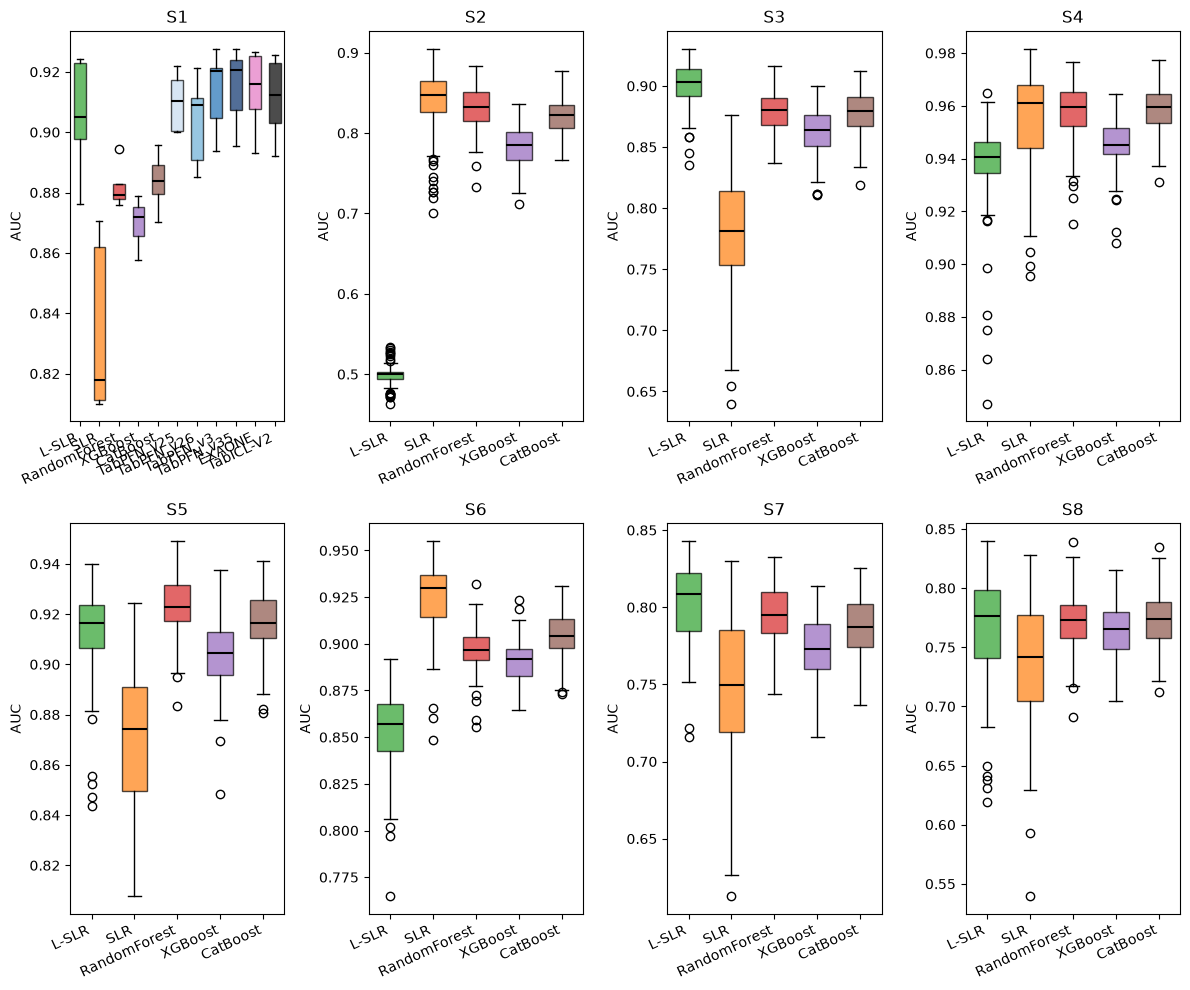

In [5]:
plot_boxplots_grid_lands(baseline, base_names, labels=base_labels, metric='AUC',
                         dir=PLOTS_PATH, save_path='auc_box.png')


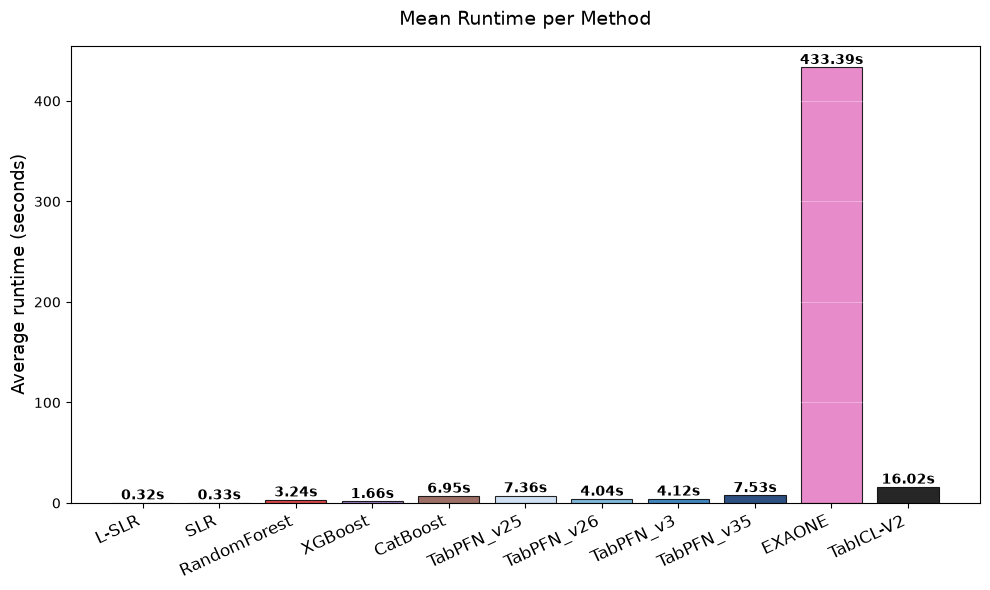

In [6]:
plot_runtime_barplot_simple(baseline, base_names, labels=base_labels,
                            dir=PLOTS_PATH, save_path='runtime.png')


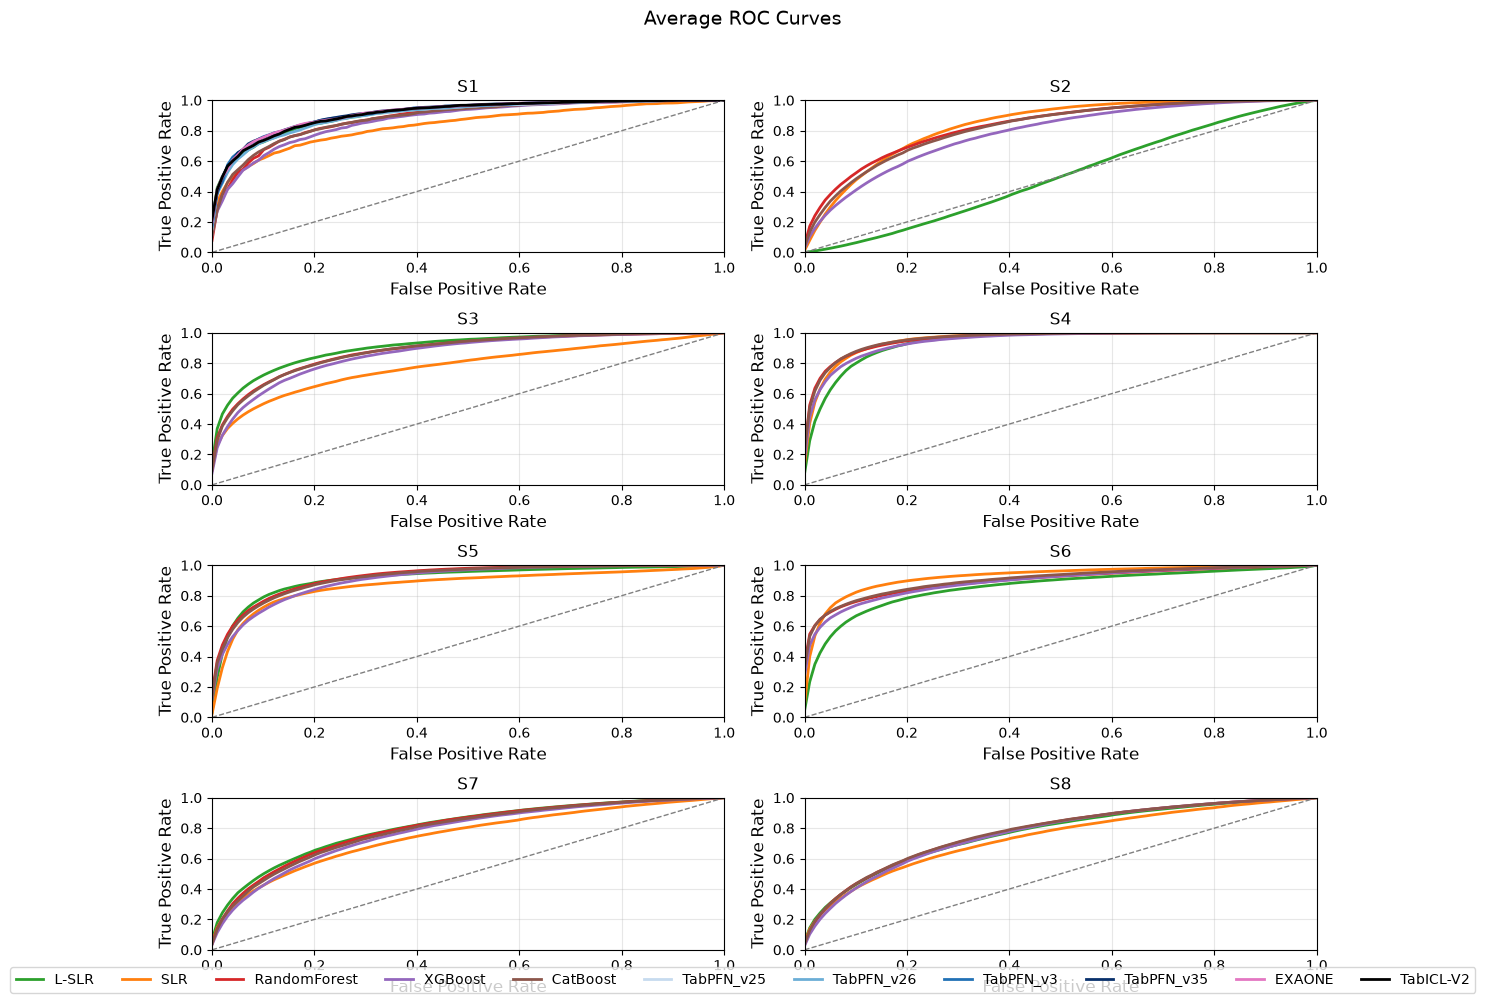

In [7]:
plot_roc_curves_grid(baseline, base_names, labels=base_labels,
                     dir=PLOTS_PATH, save_path='roc.png')


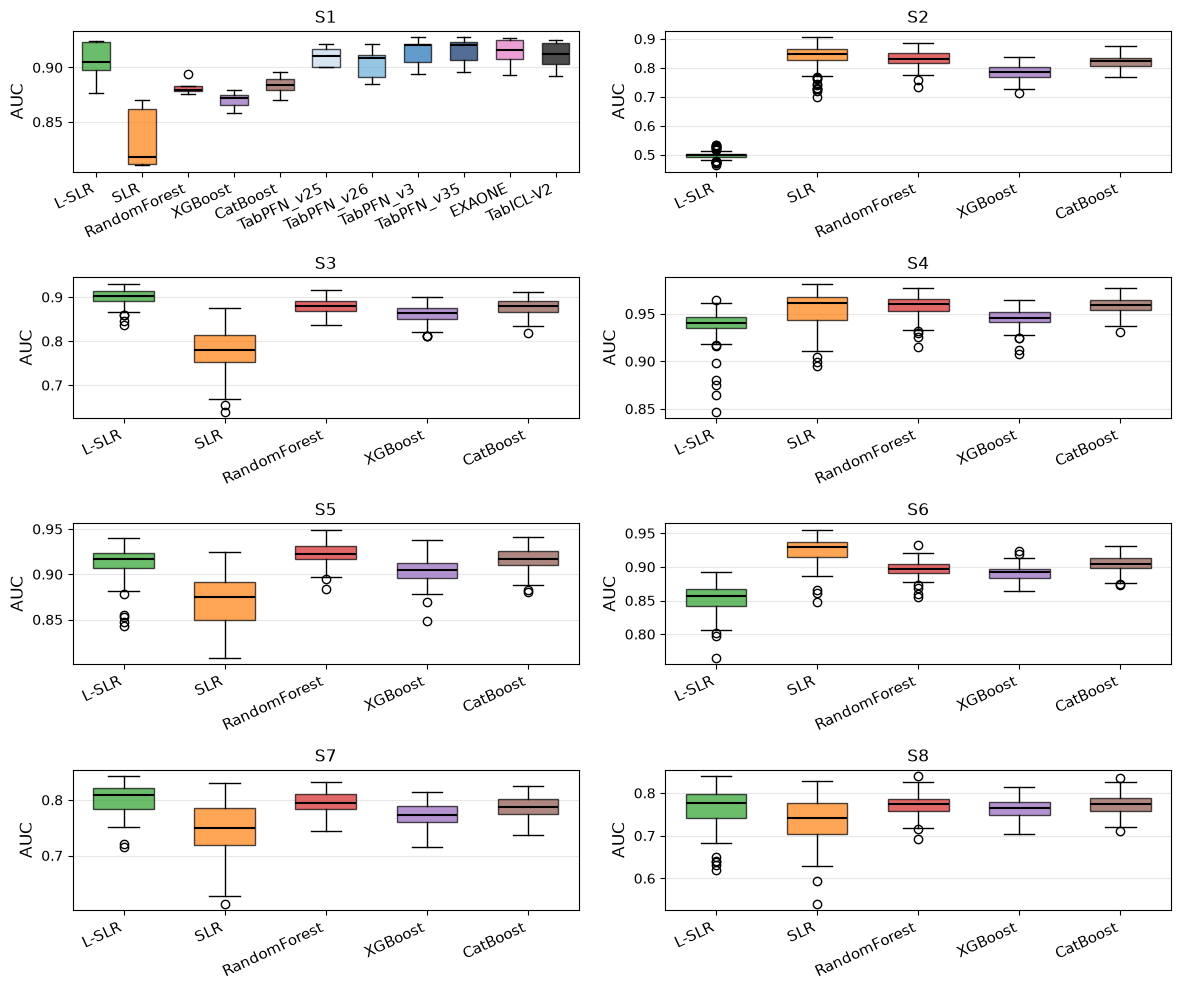

In [8]:
plot_boxplots_grid(baseline, base_names, labels=base_labels, metric='AUC',
                   dir=PLOTS_PATH, save_path='auc_box2.png')


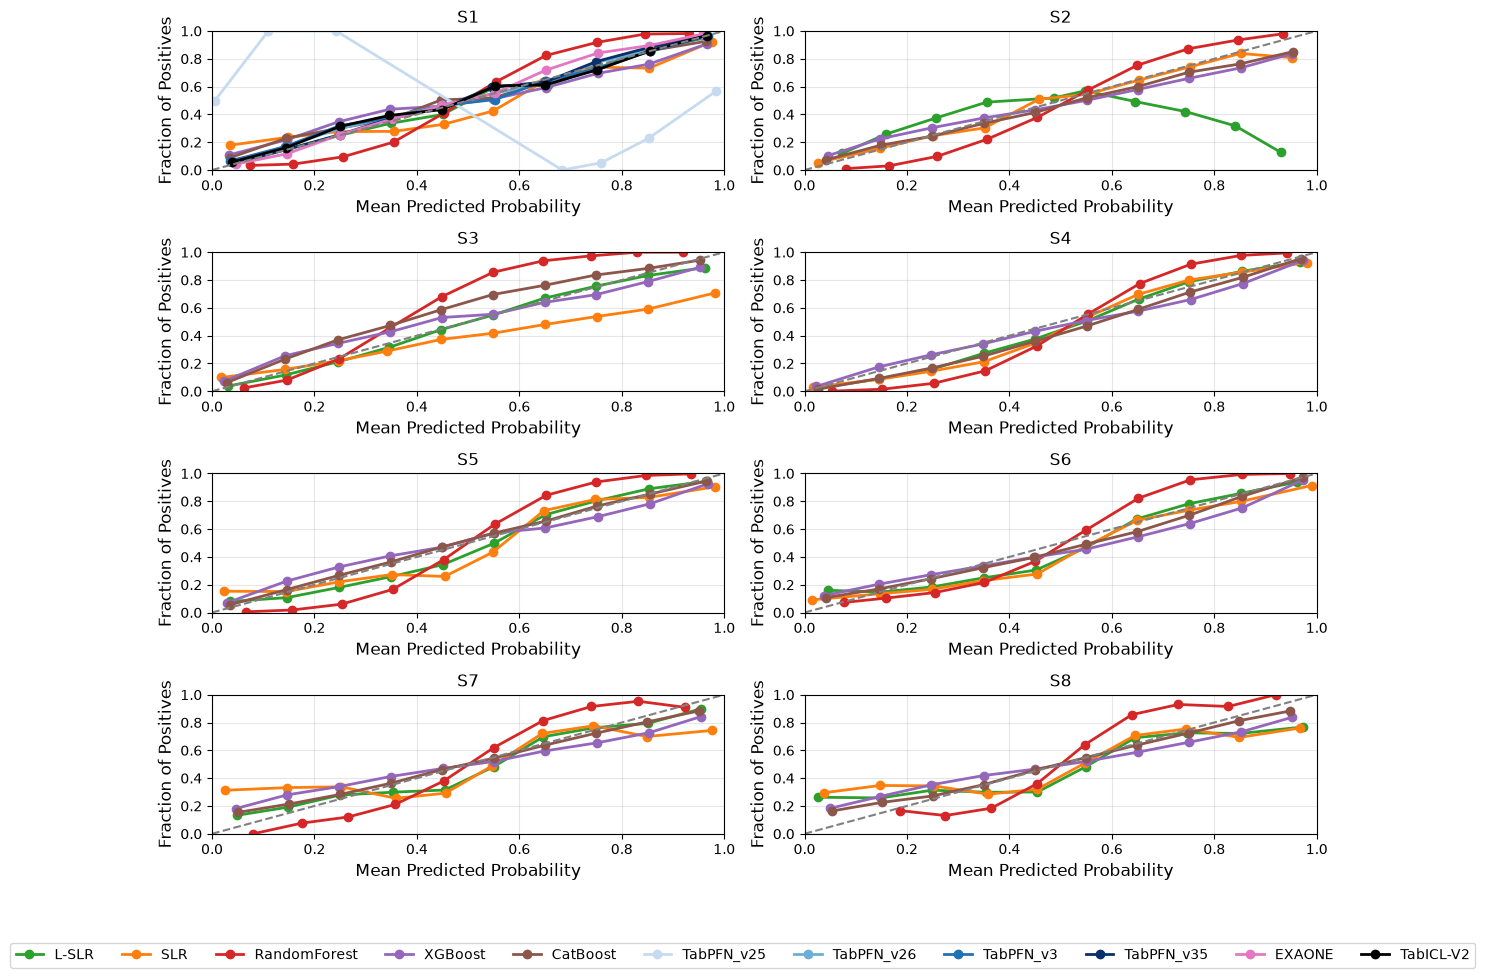

In [9]:
plot_calibration_grid(baseline, base_names, labels=base_labels,
                      dir=PLOTS_PATH, save_path='calib.png')


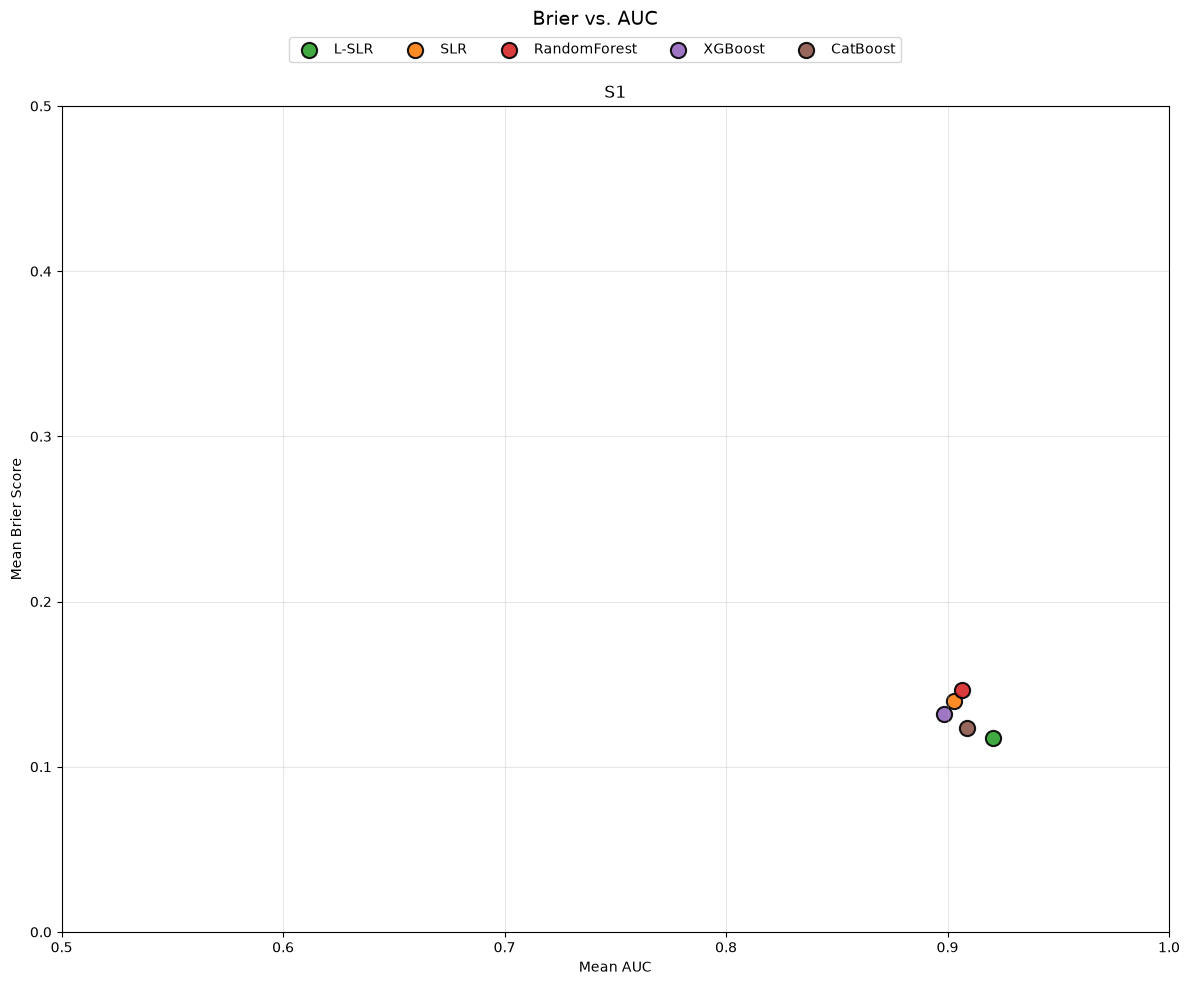

In [10]:
plot_brier_vs_auc_grid(sensitivity, sens_names, labels=sens_labels,
                       dir=PLOTS_PATH, save_path='brier_auc.png')